In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [6]:
df =pd.read_csv("solar_system.csv")
print(df.shape)

(20, 11)


In [7]:
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 20
Number of columns: 11


In [8]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [9]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [11]:
print(df.columns)

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [16]:
print(df.index)

RangeIndex(start=0, stop=20, step=1)


In [14]:
orbital_period = df.iloc[0, 1:].astype(float)
perihelion = df.iloc[1, 1:].astype(float)
aphelion = df.iloc[2, 1:].astype(float)

In [ ]:
"""
 a)perihelion --> closest point in a planet's orbit to the sun
 b) aphelion --> farthest point in a planet's orbit from the sun
 c) Semi-major axis --> the aberhae distance between the periheion and aphelion
"""

In [17]:
#SEMI MAJOR AXIS
semi_major_axis = (perihelion + aphelion) / 2
semi_major_axis_row = pd.Series(["Semi-major axis (AU)"] + list(semi_major_axis.values), index=df.columns)
df = pd.concat([df, semi_major_axis_row.to_frame().T], ignore_index=True)

df["Semi-major axis (AU)"] = semi_major_axis
print("New DataFrame shape:", df.shape)

New DataFrame shape: (21, 12)


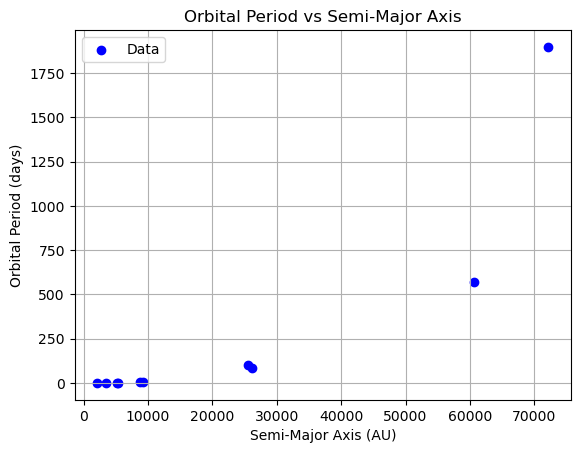

In [18]:
#plot semi-major axis vs orbital period
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Data')
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (days)")
plt.title("Orbital Period vs Semi-Major Axis")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
def keplers_third_law(a, m):
    return m * a ** 1.5

# Initial guess for m (the proportionality constant)
p0 = [1]

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=p0)
m_fit = popt[0]

print(f"Fitted model: P = {m_fit:.2f} * a^(3/2)")


Fitted model: P = 0.00 * a^(3/2)


In [22]:
#REDUCED CHI^2
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals ** 2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")

Reduced Chi-Squared: 66815.87


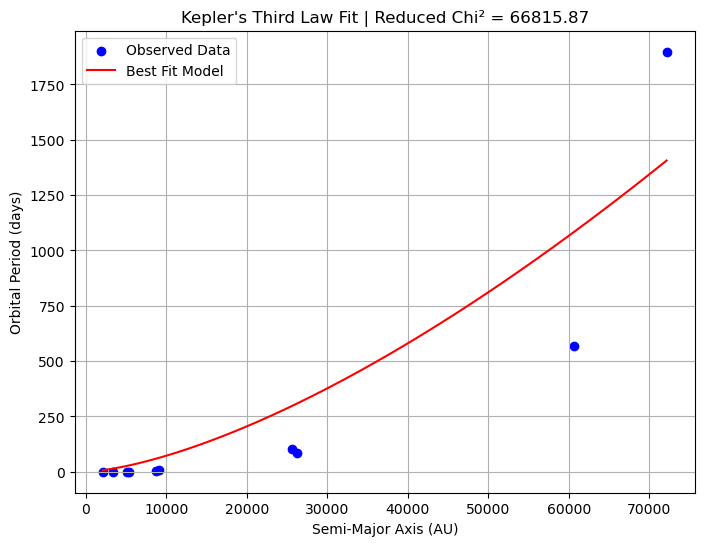

In [23]:
#FITTED MODEL
a_fit = np.linspace(min(semi_major_axis), max(semi_major_axis), 100)
p_fit = keplers_third_law(a_fit, m_fit)

plt.figure(figsize=(8, 6))
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Observed Data')
plt.plot(a_fit, p_fit, color='red', label='Best Fit Model')
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (days)")
plt.title(f"Kepler's Third Law Fit | Reduced Chi² = {chi2_reduced:.2f}")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
df.to_csv("kepler.csv", index=False)